# CME538 - Introduction to Data Science

## Tutorial 6 - Geospatial Data Analysis

In this tutorial, we will learn how to work with **geospatial data** using Python.

Geospatial data is data that is associated with a location on the Earth's surface. Examples include:

* locations of bicycle-sharing stations
* road and bikeway networks
* neighbourhood or district boundaries
* building locations
* GPS measurements
* environmental observations


We will use real data from **Paris**, including:

* public bicycle-sharing stations
* Paris district boundaries

We will use:

* **GeoPandas** for geospatial data
* **Shapely** for geometric objects
* **Matplotlib** for static maps
* **Folium** for interactive maps

By the end of the tutorial, you will be able to load, inspect, visualize, and perform basic spatial analysis on geographic data.


## 1. What Is Geospatial Data?

Geospatial data is data that describes **what something is and where it is located**.

For example, a bike station might have:

| Station   | Bikes | Latitude | Longitude |
| --------- | ----: | -------: | --------: |
| Station A |    12 |  48.8566 |    2.3522 |

The station's name and number of bikes are **attributes**, while its location is **spatial information**.

Once location is represented spatially, we can:

* plot data on a map,
* calculate distances,
* find nearby features,
* determine which area contains a feature,
* combine datasets based on geographic relationships.

This is what makes geospatial data different from ordinary tabular data.


## 2. Geometric Objects

Geospatial data represents locations and shapes using **geometric objects**.

The three basic objects are:

### Point

A **Point** represents a single location.

Examples include a bike station or GPS location.

### LineString

A **LineString** is a sequence of connected points forming a line.

Examples include roads, bikeways, and rivers.

### Polygon

A **Polygon** represents an enclosed area.

Examples include districts, neighbourhoods, and lakes.

| Geometry    | Example in this tutorial |
| ----------- | ------------------------ |
| **Point**   | Bike station             |
| **Polygon** | Paris district           |

These geometric objects allow us to perform spatial operations using Python.


## 3. GeoPandas and GeoDataFrames

If you have worked with pandas, you already know about a **DataFrame**, which stores data in rows and columns.

**GeoPandas** extends pandas to work with **geometric data**.

Its main data structure is the **GeoDataFrame**. A GeoDataFrame looks like a pandas DataFrame but includes a special `geometry` column.

For example:

| Station | Bikes | geometry |
| ------- | ----: | -------- |
| A       |    12 | Point    |
| B       |     8 | Point    |
| C       |    21 | Point    |

The `geometry` column stores the spatial object associated with each row.

GeoPandas can use these geometries to:

* visualize spatial data,
* calculate distances and areas,
* determine spatial relationships,
* and perform spatial joins.

We will use GeoPandas to work with the Paris datasets throughout this tutorial.


## 4. Coordinate Reference Systems (CRS)

A **Coordinate Reference System (CRS)** tells us how coordinates correspond to real locations on Earth.

There are two broad types of CRS we will encounter:

* **Geographic CRS** — uses longitude and latitude, usually measured in degrees.
* **Projected CRS** — represents locations on a flat coordinate system, often using metres.

For example, a location can be represented using longitude and latitude:

$$
(\text{longitude},\text{latitude})
$$

or using projected coordinates such as:

$$
(x,y)
$$

in metres.

### Why does CRS matter?

CRS matters because different coordinate systems are designed for different purposes.

For example:

* **Longitude/latitude** is useful for locating and displaying features on a map.
* **Projected CRS** is often more appropriate for calculating distances or areas.

Different projections also distort the Earth's surface in different ways. There is no single projection that is perfect for every purpose.

### EPSG Codes

CRS are commonly identified using an **EPSG code**.

For example:

```text
EPSG:4326
```

is a commonly used geographic CRS based on longitude and latitude.

GeoPandas stores the CRS as part of a GeoDataFrame. We can check it using:

```python
gdf.crs
```

and transform a GeoDataFrame to another CRS using:

```python
gdf.to_crs(...)
```

We will use these ideas when working with the Paris datasets.


## 5. Getting Started

We will use **GeoPandas** to read and analyze the Paris geospatial datasets.

Our main datasets are:

- `paris_bike_stations.geojson` — bike station locations
- `paris_districts.geojson` — Paris district boundaries

We also have versions of these datasets in different coordinate reference systems, which we will use later to understand reprojection.

We will use:

- **GeoPandas** for geospatial analysis
- **Shapely** for geometric objects
- **Matplotlib** for static maps
- **Folium** for interactive maps

In [1]:
# Import the libraries we will use throughout the tutorial

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Folium will be used later for interactive maps
import folium

# Display plots inside the notebook
%matplotlib inline

## 6. Loading Geospatial Data

GeoPandas can read many common geospatial file formats, including:

- GeoJSON (`.geojson`)
- GeoPackage (`.gpkg`)
- Shapefile (`.shp`)

We will start with the Paris bike stations and district boundaries.

The result of `gpd.read_file()` is a **GeoDataFrame**.


In [2]:
# Load the Paris bike station locations
bike_stations = gpd.read_file("paris_bike_stations.geojson")

# Load the Paris district boundaries
districts = gpd.read_file("paris_districts.geojson")

# Check that both datasets loaded successfully
print("Bike stations:", bike_stations.shape)
print("Districts:", districts.shape)

Bike stations: (1226, 4)
Districts: (80, 4)


## 7. Inspecting a GeoDataFrame

A GeoDataFrame behaves much like a pandas DataFrame.

We can use familiar pandas operations such as:

- `.head()`
- `.info()`
- `.columns`
- `.shape`

But a GeoDataFrame also contains a **geometry column** and a **CRS**.

In [3]:
# Look at the first few bike stations
bike_stations.head()

,name,bike_stands,available_bikes,geometry
0,14002 - RASPAIL QUINET,44,4,POINT (2.32956 48.8392)
1,20503 - COURS DE VINCENNES PYRÉNÉES,21,3,POINT (2.40591 48.84772)
2,20011 - PYRÉNÉES-DAGORNO,21,0,POINT (2.40517 48.8555)
3,31008 - VINCENNES (MONTREUIL),56,0,POINT (2.43737 48.8577)
4,43006 - MINIMES (VINCENNES),28,27,POINT (2.43079 48.84149)


In [4]:
# Examine the columns and data types
bike_stations.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1226 entries, 0 to 1225
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             1226 non-null   str     
 1   bike_stands      1226 non-null   int32   
 2   available_bikes  1226 non-null   int32   
 3   geometry         1226 non-null   geometry
dtypes: geometry(1), int32(2), str(1)
memory usage: 28.9 KB


In [5]:
# Check the CRS of the bike station data
bike_stations.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
# Check the CRS of the district data
districts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 8. Working with Geometry

The `geometry` column contains the spatial object associated with each observation.

For the bike stations, the geometry should be **Point** objects.

For the districts, the geometry should be **Polygon** objects.

GeoPandas provides useful geometric properties and methods through the `geometry` column.

In [7]:
# See what type of geometry each dataset contains

print("Bike stations:")
print(bike_stations.geometry.geom_type.value_counts())

print("\nDistricts:")
print(districts.geometry.geom_type.value_counts())

Bike stations:
Point    1226
Name: count, dtype: int64

Districts:
Polygon    80
Name: count, dtype: int64


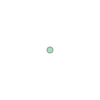

In [8]:
# Look at the geometry of the first bike station
bike_stations.geometry.iloc[0]

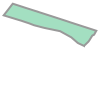

In [9]:
# Look at the geometry of the first district
districts.geometry.iloc[0]

## 9. Static Maps with GeoPandas

GeoPandas can create maps using the `.plot()` method.

Unlike a normal pandas plot, GeoPandas uses the `geometry` column to determine where each feature should appear.

We can therefore visualize our spatial data without manually specifying latitude and longitude.

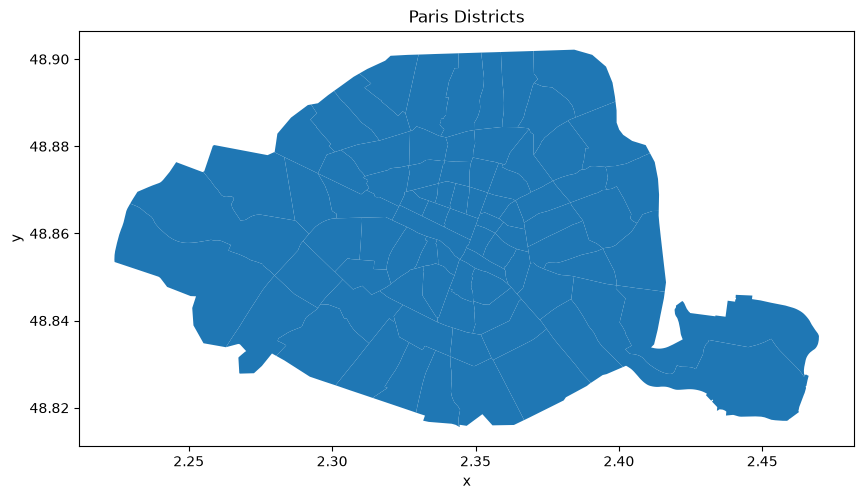

In [10]:
# Plot the Paris district boundaries

districts.plot(figsize=(10, 8))

plt.title("Paris Districts")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

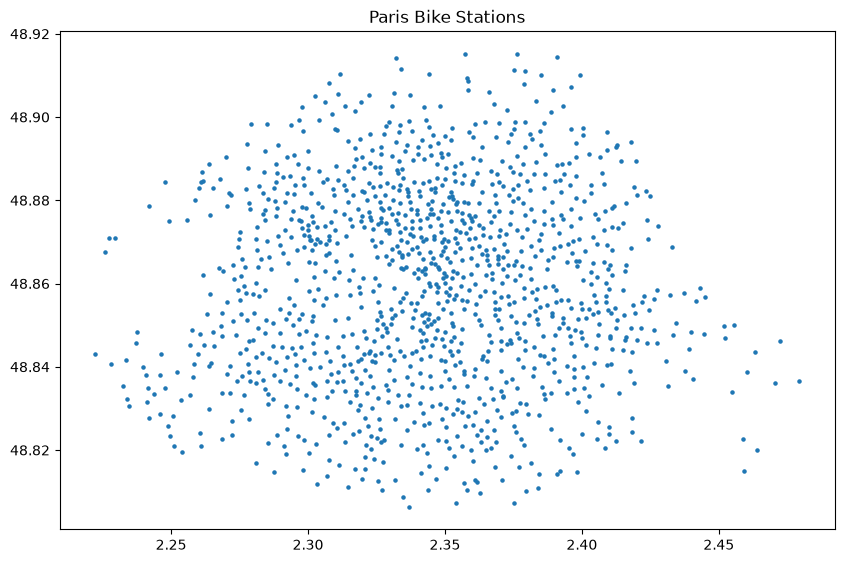

In [11]:
# Plot the bike station locations

bike_stations.plot(
    figsize=(10, 8),
    markersize=5
)

plt.title("Paris Bike Stations")
plt.show()

## 10. Plotting Multiple Spatial Layers

One of the advantages of geospatial visualization is that we can overlay different datasets on the same map.

For example, we can plot:

- Paris district boundaries
- bike station locations

This allows us to visually examine how the stations are distributed across the city.

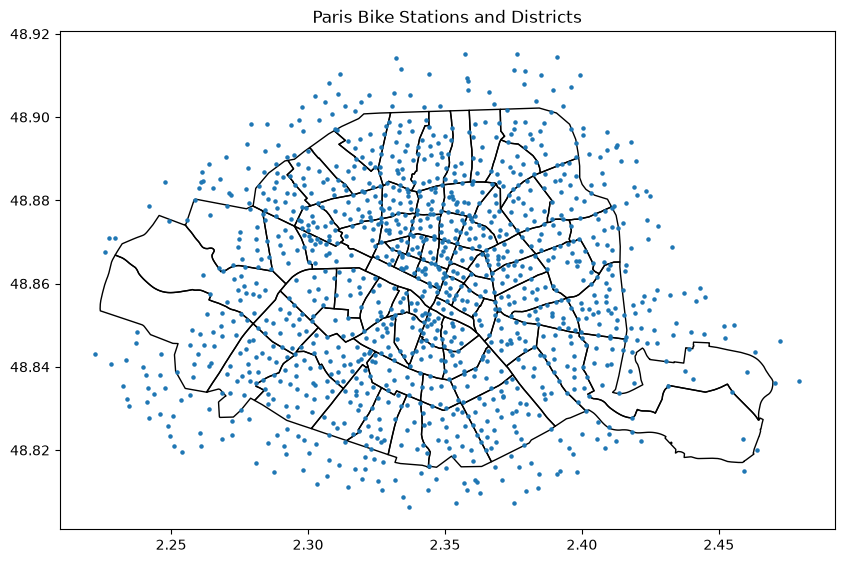

In [12]:
# Create one figure and plot both datasets on it

fig, ax = plt.subplots(figsize=(10, 8))

# Plot district boundaries first
districts.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black"
)

# Plot bike stations on top
bike_stations.plot(
    ax=ax,
    markersize=5
)

ax.set_title("Paris Bike Stations and Districts")

plt.show()

## 11. Coordinate Reference Systems in Practice

We saw earlier that a CRS determines how coordinates are represented.

This becomes especially important when combining datasets.

Two GeoDataFrames should generally use the **same CRS** before we perform spatial operations between them.

We can compare their CRS using `.crs`.

In [13]:
# Compare the CRS of our two datasets

print("Bike stations CRS:")
print(bike_stations.crs)

print("\nDistricts CRS:")
print(districts.crs)

Bike stations CRS:
EPSG:4326

Districts CRS:
EPSG:4326


### Reprojecting Data

GeoPandas provides `.to_crs()` to transform a GeoDataFrame into another CRS.

Importantly, `.to_crs()` **changes the coordinate representation**; it does not change the actual geographic location.

We will use the UTM version of the Paris datasets later when working with distances and spatial operations.

In [14]:
# Load the versions of the datasets that use a projected CRS

bike_stations_utm = gpd.read_file(
    "paris_sharing_bike_stations_utm.geojson"
)

districts_utm = gpd.read_file(
    "paris_districts_utm.geojson"
)

# Check their CRS
print("Bike stations UTM CRS:")
print(bike_stations_utm.crs)

print("\nDistricts UTM CRS:")
print(districts_utm.crs)

Bike stations UTM CRS:
EPSG:32631

Districts UTM CRS:
EPSG:32631


In [15]:
# Reproject the original bike station data to the CRS of the UTM dataset

bike_stations_projected = bike_stations.to_crs(
    bike_stations_utm.crs
)

# Confirm the new CRS
bike_stations_projected.crs

<Projected CRS: EPSG:32631>
Name: WGS 84 / UTM zone 31N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 0°E and 6°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Andorra. Belgium. Benin. Burkina Faso. Denmark - North Sea. France. Germany - North Sea. Ghana. Luxembourg. Mali. Netherlands. Niger. Nigeria. Norway. Spain. Togo. United Kingdom (UK) - North Sea.
- bounds: (0.0, 0.0, 6.0, 84.0)
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 12. Distance and Area

Distances and areas depend on the coordinate system being used.

For meaningful distance or area calculations, we generally want a **projected CRS with suitable units**, such as metres.

The UTM version of our Paris data is useful for this purpose.

For example, we can calculate the area of each Paris district.

In [16]:
# Calculate the area of each district
# The projected CRS uses metres, so area is returned in square metres.

districts_utm["area_m2"] = districts_utm.geometry.area

# Display the district names and their areas
districts_utm[["area_m2", "geometry"]].head()

,area_m2,geometry
0,868537.873059,"POLYGON ((451922.133 5411438.484, 451922.08 54..."
1,412237.139604,"POLYGON ((452278.419 5412160.893, 452192.407 5..."
2,273549.361878,"POLYGON ((451553.806 5412340.522, 451528.058 5..."
3,269311.055565,"POLYGON ((451004.908 5412654.095, 450960.64 54..."
4,187909.748885,"POLYGON ((451328.752 5412991.278, 451294.721 5..."


In [17]:
# Convert square metres to square kilometres
districts_utm["area_km2"] = districts_utm["area_m2"] / 1_000_000

# Display the calculated areas
districts_utm[["area_km2"]].head()

,area_km2
0,0.868538
1,0.412237
2,0.273549
3,0.269311
4,0.187910


We can also calculate the distance between two point geometries.

Because our projected CRS uses metres, the resulting distance is expressed in metres.

In [18]:
# Calculate the distance between the first two bike stations

point_1 = bike_stations_projected.geometry.iloc[0]
point_2 = bike_stations_projected.geometry.iloc[1]

distance_m = point_1.distance(point_2)

print(f"Distance: {distance_m:.1f} metres")

Distance: 5681.8 metres


## 13. Spatial Relationships

Geospatial analysis allows us to ask questions about **where objects are relative to one another**.

For example:

- Is a point inside a polygon?
- Do two geometries intersect?
- Is one geometry within another?
- How far apart are two objects?

These relationships are based on geometry rather than ordinary column values.

In [19]:
# Select the first bike station and first district

station = bike_stations_projected.geometry.iloc[0]
district = districts_utm.geometry.iloc[0]

# Check whether the station is inside the district
station.within(district)

False

In [20]:
# Check whether the two geometries intersect

station.intersects(district)

False

## 14. Spatial Joins

A **spatial join** combines datasets based on their geographic relationship.

This is different from a normal pandas merge.

Instead of matching rows using a common column, a spatial join can match features based on relationships such as:

- within
- intersects
- contains

For example, we can determine **which Paris district contains each bike station**.

In [21]:
# Make sure both datasets use the same CRS

bike_stations_projected = bike_stations_projected.to_crs(
    districts_utm.crs
)

# Spatially join each bike station to the district containing it

stations_with_district = gpd.sjoin(
    bike_stations_projected,
    districts_utm,
    predicate="within",
    how="left"
)

# Inspect the result
stations_with_district.head()

,name,bike_stands,available_bikes,geometry,index_right,id,district_name,population,area_m2,area_km2
0,14002 - RASPAIL QUINET,44,4,POINT (450804.449 5409797.268),52.0,53.0,Montparnasse,18570.0,1.125644e+06,1.125644
1,20503 - COURS DE VINCENNES PYRÉNÉES,21,3,POINT (456414.352 5410698.461),79.0,80.0,Charonne,62901.0,2.089783e+06,2.089783
2,20011 - PYRÉNÉES-DAGORNO,21,0,POINT (456366.909 5411563.32),79.0,80.0,Charonne,62901.0,2.089783e+06,2.089783
3,31008 - VINCENNES (MONTREUIL),56,0,POINT (458730.707 5411789.995),NaN,NaN,NaN,NaN,NaN,NaN
4,43006 - MINIMES (VINCENNES),28,27,POINT (458234.93 5409991.067),NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Check how many bike stations were assigned to each district

district_counts = (
    stations_with_district
    .groupby("index_right")
    .size()
    .sort_values(ascending=False)
)

district_counts.head(10)

index_right
49.0    33
79.0    30
45.0    26
56.0    26
59.0    22
57.0    22
68.0    22
60.0    21
55.0    20
69.0    20
dtype: int64

The spatial join has added information from the district dataset to each bike station.

This lets us move from a question about individual points:

> Where is each bike station?

to a question involving geographic regions:

> Which district contains each bike station?

## 15. Aggregating Spatial Data

Once bike stations have been assigned to districts, we can summarize the data by district.

For example, we can count the number of bike stations in each district.

This combines a spatial operation with a familiar pandas `groupby()`.

In [23]:
# Count bike stations in each district

station_counts = (
    stations_with_district
    .groupby("index_right")
    .size()
    .rename("station_count")
)

station_counts.head()

index_right
0.0     4
1.0    13
2.0     6
3.0     5
4.0     4
Name: station_count, dtype: int64

In [24]:
# Add the station counts back to the district GeoDataFrame

districts_with_counts = districts_utm.copy()

districts_with_counts["station_count"] = (
    station_counts
    .reindex(districts_with_counts.index)
    .fillna(0)
)

In [25]:
# Inspect the districts with their station counts

districts_with_counts[
    ["station_count", "geometry"]
].head()

,station_count,geometry
0,4,"POLYGON ((451922.133 5411438.484, 451922.08 54..."
1,13,"POLYGON ((452278.419 5412160.893, 452192.407 5..."
2,6,"POLYGON ((451553.806 5412340.522, 451528.058 5..."
3,5,"POLYGON ((451004.908 5412654.095, 450960.64 54..."
4,4,"POLYGON ((451328.752 5412991.278, 451294.721 5..."


## 16. Visualizing Spatial Aggregations

We can visualize the number of bike stations in each district using a **choropleth map**.

A choropleth map uses different shades to represent the value of a variable across geographic regions.

Here, darker or lighter districts will represent different numbers of bike stations.

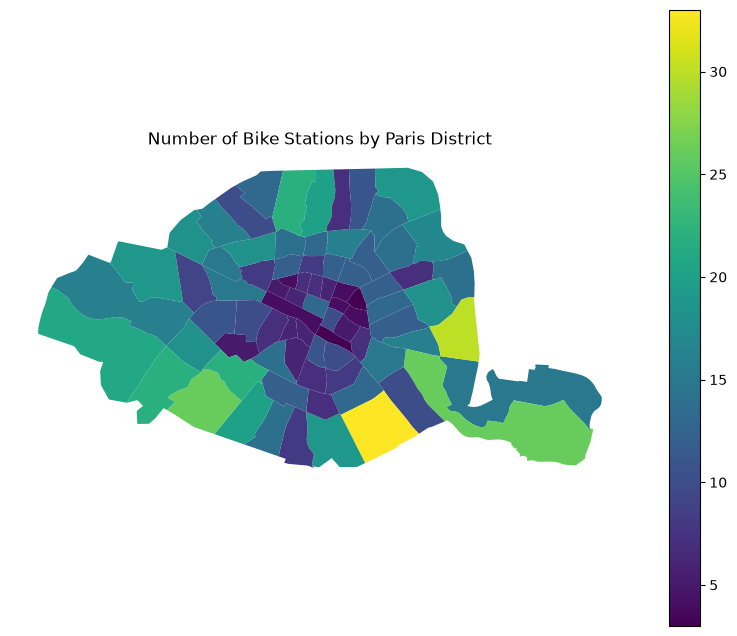

In [26]:
# Plot the number of bike stations by district

districts_with_counts.plot(
    column="station_count",
    figsize=(10, 8),
    legend=True
)

plt.title("Number of Bike Stations by Paris District")
plt.axis("off")
plt.show()

## 17. Interactive Maps with Folium

GeoPandas is useful for static maps, but interactive maps can be useful for exploring spatial data.

**Folium** creates interactive maps using the Leaflet mapping library.

Folium maps typically use geographic coordinates in longitude and latitude, so we will use the original geographic bike station data.

In [27]:
# Calculate the approximate centre of the bike station locations

center = [
    bike_stations.geometry.y.mean(),
    bike_stations.geometry.x.mean()
]

# Create an interactive map
m = folium.Map(
    location=center,
    zoom_start=12
)

m

In [28]:
# Add bike stations to the interactive map

for _, row in bike_stations.iterrows():

    # Extract latitude and longitude from the Point geometry
    latitude = row.geometry.y
    longitude = row.geometry.x

    folium.CircleMarker(
        location=[latitude, longitude],
        radius=3,
        popup=str(row.iloc[0])
    ).add_to(m)

m

We can also add the Paris district boundaries to the interactive map.

GeoJSON is a format that Folium can display directly, making it convenient for adding GeoDataFrames to interactive maps.

In [29]:
# Create a new interactive map

m = folium.Map(
    location=center,
    zoom_start=12
)

# Add district boundaries
folium.GeoJson(
    districts.to_json(),
    name="Paris Districts"
).add_to(m)

# Add bike stations
for _, row in bike_stations.iterrows():

    latitude = row.geometry.y
    longitude = row.geometry.x

    folium.CircleMarker(
        location=[latitude, longitude],
        radius=3
    ).add_to(m)

m

## 19. Putting It Together

We can now combine the ideas from this tutorial to answer a more realistic question:

> **How are bike stations distributed across Paris districts?**

To answer this, we:

1. loaded point and polygon datasets,
2. checked their CRS,
3. transformed them to a common projected CRS,
4. performed a spatial join,
5. counted stations by district,
6. and visualized the result.

In [30]:
# Display the districts ordered by the number of bike stations

districts_with_counts[
    ["station_count", "geometry"]
].sort_values(
    "station_count",
    ascending=False
).head(10)

,station_count,geometry
49,33,"POLYGON ((453583.764 5407352.445, 453528.804 5..."
79,30,"POLYGON ((457155.511 5410584.127, 457153.394 5..."
45,26,"POLYGON ((456790.759 5408686.978, 456841.941 5..."
56,26,"POLYGON ((448948.777 5409948.354, 449001.82 54..."
59,22,"POLYGON ((447334.498 5409356.211, 447449.418 5..."
57,22,"POLYGON ((449095.821 5410779.852, 449182.384 5..."
68,22,"POLYGON ((451638.745 5415782.714, 451615.777 5..."
60,21,"POLYGON ((444930.499 5411923.067, 444957.444 5..."
55,20,"POLYGON ((450187.157 5409880.758, 450204.769 5..."
69,20,"POLYGON ((452477.21 5415584.554, 452459.675 54..."


## 20. Finding the Nearest Feature

Another common spatial question is:

> Which bike station is closest to a given location?

GeoPandas provides `sjoin_nearest()` for nearest-neighbour spatial joins.

This is useful when the relationship is based on **distance** rather than containment or intersection.

In [31]:
# Compare each bike station with the other bike stations
# and find the nearest other station.

stations_nearest = gpd.sjoin_nearest(
    bike_stations_projected,
    bike_stations_projected,
    how="left",
    distance_col="distance_m"
)

stations_nearest.head()

,name_left,bike_stands_left,available_bikes_left,geometry,index_right,name_right,bike_stands_right,available_bikes_right,distance_m
0,14002 - RASPAIL QUINET,44,4,POINT (450804.449 5409797.268),0,14002 - RASPAIL QUINET,44,4,0.0
1,20503 - COURS DE VINCENNES PYRÉNÉES,21,3,POINT (456414.352 5410698.461),1,20503 - COURS DE VINCENNES PYRÉNÉES,21,3,0.0
2,20011 - PYRÉNÉES-DAGORNO,21,0,POINT (456366.909 5411563.32),2,20011 - PYRÉNÉES-DAGORNO,21,0,0.0
3,31008 - VINCENNES (MONTREUIL),56,0,POINT (458730.707 5411789.995),3,31008 - VINCENNES (MONTREUIL),56,0,0.0
4,43006 - MINIMES (VINCENNES),28,27,POINT (458234.93 5409991.067),4,43006 - MINIMES (VINCENNES),28,27,0.0


In [32]:
# Remove matches where a station was matched to itself
# and inspect the nearest distances

nearest_other = stations_nearest[
    stations_nearest.index != stations_nearest.index_right
]

nearest_other[
    ["distance_m"]
].head()

,distance_m


## 21. GeoPackage Files

Geospatial data can be stored in different file formats.

We have also been provided with:

`paris_bike_stations_mercator.gpkg`

A **GeoPackage** can store geospatial data in a single database-like file.

GeoPandas can read it using the same `read_file()` function.

In [33]:
# Load the GeoPackage dataset

bike_stations_gpkg = gpd.read_file(
    "paris_bike_stations_mercator.gpkg"
)

# Inspect the data
bike_stations_gpkg.head()

,name,bike_stands,available_bikes,geometry
0,14002 - RASPAIL QUINET,44,4,POINT (259324.887 6247620.771)
1,20503 - COURS DE VINCENNES PYRÉNÉES,21,3,POINT (267824.377 6249062.894)
2,20011 - PYRÉNÉES-DAGORNO,21,0,POINT (267742.135 6250378.469)
3,31008 - VINCENNES (MONTREUIL),56,0,POINT (271326.638 6250750.824)
4,43006 - MINIMES (VINCENNES),28,27,POINT (270594.689 6248007.705)


In [34]:
# Check its CRS

bike_stations_gpkg.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 22. Summary

In this tutorial, we used real Paris geospatial data to learn how to:

- represent locations using **geometric objects**,
- work with **GeoDataFrames**,
- inspect and transform **CRS**,
- visualize spatial data with **GeoPandas**,
- calculate **areas and distances**,
- work with spatial relationships such as `within()` and `intersects()`,
- perform **spatial joins**,
- aggregate spatial data by geographic regions,
- create **choropleth maps**,
- create interactive maps with **Folium**,
- and find nearby spatial features.

The key idea is that geospatial analysis extends ordinary data analysis by incorporating **location and spatial relationships** into the analysis.

In [35]:
# Quick check: what have we created?

print("Bike stations:", len(bike_stations))
print("Paris districts:", len(districts))
print("Station-district spatial join:", len(stations_with_district))
print("Projected CRS:", districts_utm.crs)

Bike stations: 1226
Paris districts: 80
Station-district spatial join: 1226
Projected CRS: EPSG:32631
